# Topic Modeling with Gensim & Scikit-learn **LDA** (Gensim) + **NMF** (Non-negative Matrix Factorization) 

## 1. Prerequisites & Downloads

In [3]:
# Uncomment and run once if packages are not installed
#!pip install gensim pyLDAvis spacy scikit-learn nltk matplotlib pandas numpy
# !python -m spacy download en_core_web_sm
# !python -c "import nltk; nltk.download('stopwords')" 

## 2. Imports

In [25]:
import re
import numpy as np
import pandas as pd
from pprint import pprint

# Gensim
import gensim
import gensim.corpora as corpora
from gensim.utils import simple_preprocess
from gensim.models import CoherenceModel
from gensim.models import Nmf as GensimNmf  # Gensim's online NMF

# Scikit-learn NMF
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer

# spaCy for lemmatization
import spacy

# Plotting tools
# Plotting tools
import pyLDAvis
import pyLDAvis.gensim  # updated module name
import matplotlib.pyplot as plt
%matplotlib inline

import matplotlib.gridspec as gridspec

import logging
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.ERROR)

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

## 3. Stop Words

In [7]:
# NLTK Stop words
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

stop_words = stopwords.words('english')
stop_words.extend(['from', 'subject', 're', 'edu', 'use'])

[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1123)>


## 4. Load the 20-Newsgroups Dataset

In [8]:
import requests

url = "https://raw.githubusercontent.com/selva86/datasets/master/newsgroups.json"
resp = requests.get(url, verify=False)
df = pd.DataFrame(resp.json())
print(f"Dataset shape: {df.shape}")
df.head()

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/urllib3/connectionpool.py:1064: InsecureRequestWarning: Unverified HTTPS request is being made to host 'raw.githubusercontent.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  warnings.warn(


Dataset shape: (11314, 3)


,content,target,target_names
0,From: lerxst@wam.umd.edu (where's my thing)\nS...,7,rec.autos
1,From: guykuo@carson.u.washington.edu (Guy Kuo)...,4,comp.sys.mac.hardware
2,From: twillis@ec.ecn.purdue.edu (Thomas E Will...,4,comp.sys.mac.hardware
3,From: jgreen@amber (Joe Green)\nSubject: Re: W...,1,comp.graphics
4,From: jcm@head-cfa.harvard.edu (Jonathan McDow...,14,sci.space


## 5. Text Cleaning

In [9]:
# Convert to list
data = df.content.values.tolist()

# Remove emails
data = [re.sub(r'\S*@\S*\s?', '', doc) for doc in data]

# Remove newline characters
data = [re.sub(r'\s+', ' ', doc) for doc in data]

# Remove single quotes
data = [re.sub(r"\'", "", doc) for doc in data]

pprint(data[:1], width=120)

['From: (wheres my thing) Subject: WHAT car is this!? Nntp-Posting-Host: rac3.wam.umd.edu Organization: University of '
 'Maryland, College Park Lines: 15 I was wondering if anyone out there could enlighten me on this car I saw the other '
 'day. It was a 2-door sports car, looked to be from the late 60s/ early 70s. It was called a Bricklin. The doors were '
 'really small. In addition, the front bumper was separate from the rest of the body. This is all I know. If anyone '
 'can tellme a model name, engine specs, years of production, where this car is made, history, or whatever info you '
 'have on this funky looking car, please e-mail. Thanks, - IL ---- brought to you by your neighborhood Lerxst ---- ']


## 6. Tokenization

In [10]:
def sent_to_words(sentences):
    for sentence in sentences:
        yield gensim.utils.simple_preprocess(str(sentence), deacc=True)

data_words = list(sent_to_words(data))
print(data_words[:1])

[['from', 'wheres', 'my', 'thing', 'subject', 'what', 'car', 'is', 'this', 'nntp', 'posting', 'host', 'rac', 'wam', 'umd', 'edu', 'organization', 'university', 'of', 'maryland', 'college', 'park', 'lines', 'was', 'wondering', 'if', 'anyone', 'out', 'there', 'could', 'enlighten', 'me', 'on', 'this', 'car', 'saw', 'the', 'other', 'day', 'it', 'was', 'door', 'sports', 'car', 'looked', 'to', 'be', 'from', 'the', 'late', 'early', 'it', 'was', 'called', 'bricklin', 'the', 'doors', 'were', 'really', 'small', 'in', 'addition', 'the', 'front', 'bumper', 'was', 'separate', 'from', 'the', 'rest', 'of', 'the', 'body', 'this', 'is', 'all', 'know', 'if', 'anyone', 'can', 'tellme', 'model', 'name', 'engine', 'specs', 'years', 'of', 'production', 'where', 'this', 'car', 'is', 'made', 'history', 'or', 'whatever', 'info', 'you', 'have', 'on', 'this', 'funky', 'looking', 'car', 'please', 'mail', 'thanks', 'il', 'brought', 'to', 'you', 'by', 'your', 'neighborhood', 'lerxst']]


## 7. Build Bigram & Trigram Models

In [11]:
# Build bigram and trigram models
bigram = gensim.models.Phrases(data_words, min_count=5, threshold=100)
trigram = gensim.models.Phrases(bigram[data_words], threshold=100)

bigram_mod = gensim.models.phrases.Phraser(bigram)
trigram_mod = gensim.models.phrases.Phraser(trigram)

print(trigram_mod[bigram_mod[data_words[0]]])

['from', 'wheres', 'my', 'thing', 'subject', 'what', 'car', 'is', 'this', 'nntp_posting_host', 'rac_wam_umd_edu', 'organization', 'university', 'of', 'maryland_college_park', 'lines', 'was', 'wondering', 'if', 'anyone', 'out', 'there', 'could', 'enlighten', 'me', 'on', 'this', 'car', 'saw', 'the', 'other', 'day', 'it', 'was', 'door', 'sports', 'car', 'looked', 'to', 'be', 'from', 'the', 'late', 'early', 'it', 'was', 'called', 'bricklin', 'the', 'doors', 'were', 'really', 'small', 'in', 'addition', 'the', 'front_bumper', 'was', 'separate', 'from', 'the', 'rest', 'of', 'the', 'body', 'this', 'is', 'all', 'know', 'if', 'anyone', 'can', 'tellme', 'model', 'name', 'engine', 'specs', 'years', 'of', 'production', 'where', 'this', 'car', 'is', 'made', 'history', 'or', 'whatever', 'info', 'you', 'have', 'on', 'this', 'funky', 'looking', 'car', 'please', 'mail', 'thanks', 'il', 'brought', 'to', 'you', 'by', 'your', 'neighborhood', 'lerxst']


## 8. Preprocessing Helper Functions

In [12]:
def remove_stopwords(texts):
    return [[word for word in simple_preprocess(str(doc))
             if word not in stop_words] for doc in texts]

def make_bigrams(texts):
    return [bigram_mod[doc] for doc in texts]

def make_trigrams(texts):
    return [trigram_mod[bigram_mod[doc]] for doc in texts]

def lemmatization(texts, allowed_postags=['NOUN', 'ADJ', 'VERB', 'ADV']):
    """Lemmatize using spaCy, keeping only specified POS tags."""
    nlp_model = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
    texts_out = []
    for sent in texts:
        doc = nlp_model(" ".join(sent))
        texts_out.append([token.lemma_ for token in doc if token.pos_ in allowed_postags])
    return texts_out

## 9. Apply Preprocessing Pipeline

In [13]:
# Remove stop words
data_words_nostops = remove_stopwords(data_words)

# Form bigrams
data_words_bigrams = make_bigrams(data_words_nostops)

# Lemmatization (keeping noun, adj, verb, adverb)
data_lemmatized = lemmatization(data_words_bigrams,
                                allowed_postags=['NOUN', 'ADJ', 'VERB', 'ADV'])

print(data_lemmatized[:1])

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/spacy/util.py:922: UserWarning: [W095] Model 'en_core_web_sm' (3.5.0) was trained with spaCy v3.5.0 and may not be 100% compatible with the current version (3.8.7). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)


[['s', 'thing', 'car', 'nntp_poste', 'host', 'rac_wam', 'university', 'park', 'line', 'wonder', 'enlighten', 'car', 'see', 'day', 'door', 'sport', 'car', 'look', 'late', 'early', 'call', 'door', 'really', 'small', 'addition', 'separate', 'rest', 'body', 'know', 'model', 'name', 'engine', 'spec', 'year', 'production', 'car', 'make', 'history', 'info', 'funky', 'look', 'car', 'mail', 'thank', 'bring', 'neighborhood', 'lerxst']]


## 10. Create Dictionary & Corpus

In [14]:
# Create dictionary
id2word = corpora.Dictionary(data_lemmatized)

# Filter extremes: remove words that appear in <15 docs or >50% of docs
id2word.filter_extremes(no_below=15, no_above=0.5)

# Create bag-of-words corpus
corpus = [id2word.doc2bow(text) for text in data_lemmatized]

print(f"Number of unique tokens: {len(id2word)}")
print(f"Number of documents: {len(corpus)}")
print(f"\nSample BoW (first doc, first 10 entries): {corpus[0][:10]}")

Number of unique tokens: 6129
Number of documents: 11314

Sample BoW (first doc, first 10 entries): [(0, 1), (1, 1), (2, 1), (3, 1), (4, 5), (5, 1), (6, 2), (7, 1), (8, 1), (9, 1)]


## 11. Inspect Dictionary & Corpus

In [15]:
# Word for id=0
print(f"Word id 0 = '{id2word[0]}'")

# Human-readable format of corpus (first doc)
print("\nFirst document (word, freq):")
pprint([(id2word[wid], freq) for wid, freq in corpus[0][:15]])

Word id 0 = 'addition'

First document (word, freq):
[('addition', 1),
 ('body', 1),
 ('bring', 1),
 ('call', 1),
 ('car', 5),
 ('day', 1),
 ('door', 2),
 ('early', 1),
 ('engine', 1),
 ('enlighten', 1),
 ('history', 1),
 ('host', 1),
 ('info', 1),
 ('know', 1),
 ('late', 1)]


---# Part A — Latent Dirichlet Allocation (LDA)

## 12. Build the LDA Model

In [16]:
NUM_TOPICS = 10

lda_model = gensim.models.LdaMulticore(
    corpus=corpus,
    id2word=id2word,
    num_topics=NUM_TOPICS,
    random_state=100,
    chunksize=100,
    passes=10,
    alpha='asymmetric',      # asymmetric doc-topic prior
    eta='auto',              # learn word-topic prior from data
    per_word_topics=True,
    workers=2
)

## 13. View LDA Topics

In [17]:
# Print top keywords for each topic
pprint(lda_model.print_topics(num_words=7))

[(0,
  '0.019*"nntp_poste" + 0.019*"host" + 0.012*"thank" + 0.012*"mail" + '
  '0.011*"know" + 0.009*"need" + 0.009*"reply"'),
 (1,
  '0.018*"think" + 0.017*"get" + 0.017*"article" + 0.015*"go" + 0.014*"know" + '
  '0.013*"say" + 0.012*"make"'),
 (2,
  '0.021*"team" + 0.020*"game" + 0.018*"year" + 0.014*"go" + 0.013*"play" + '
  '0.011*"player" + 0.010*"win"'),
 (3,
  '0.019*"key" + 0.012*"government" + 0.011*"public" + 0.009*"state" + '
  '0.009*"right" + 0.007*"system" + 0.007*"law"'),
 (4,
  '0.013*"say" + 0.010*"people" + 0.010*"believe" + 0.007*"evidence" + '
  '0.007*"question" + 0.006*"claim" + 0.006*"make"'),
 (5,
  '0.025*"gun" + 0.022*"space" + 0.009*"year" + 0.009*"study" + 0.008*"drug" + '
  '0.008*"research" + 0.008*"firearm"'),
 (6,
  '0.016*"people" + 0.015*"kill" + 0.013*"say" + 0.011*"armenian" + '
  '0.009*"child" + 0.009*"israeli" + 0.009*"war"'),
 (7,
  '0.916*"ax" + 0.062*"max" + 0.001*"wm" + 0.001*"roster" + 0.001*"ti" + '
  '0.001*"ml" + 0.001*"gq"'),
 (8,
  '0.0

## 14. Evaluate LDA — Perplexity & Coherence

In [18]:
# Perplexity (lower is better)
print(f"Perplexity: {lda_model.log_perplexity(corpus):.4f}")

# Coherence Score (higher is better)
coherence_lda = CoherenceModel(
    model=lda_model, texts=data_lemmatized,
    dictionary=id2word, coherence='c_v'
)
print(f"Coherence Score (c_v): {coherence_lda.get_coherence():.4f}")

Perplexity: -7.0451
Coherence Score (c_v): 0.5546


## 15. Optimal Number of Topics — Coherence Grid Search

In [19]:
def compute_coherence_values(dictionary, corpus, texts, limit, start=2, step=3):
    """Compute coherence for models with different number of topics."""
    coherence_values = []
    model_list = []
    for num_topics in range(start, limit, step):
        model = gensim.models.LdaMulticore(
            corpus=corpus, id2word=dictionary, num_topics=num_topics,
            random_state=100, chunksize=100, passes=10, per_word_topics=True, workers=2
        )
        model_list.append(model)
        cm = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
        coherence_values.append(cm.get_coherence())
    return model_list, coherence_values

# Uncomment to run (takes a while):
# model_list, coherence_values = compute_coherence_values(
#     dictionary=id2word, corpus=corpus, texts=data_lemmatized,
#     start=2, limit=40, step=6
# )
# 
# x = range(2, 40, 6)
# plt.figure(figsize=(10, 5))
# plt.plot(x, coherence_values)
# plt.xlabel("Number of Topics")
# plt.ylabel("Coherence Score (c_v)")
# plt.title("LDA — Optimal Number of Topics")
# plt.grid(True, alpha=0.3)
# plt.show()

## 16. Visualize LDA with pyLDAvis

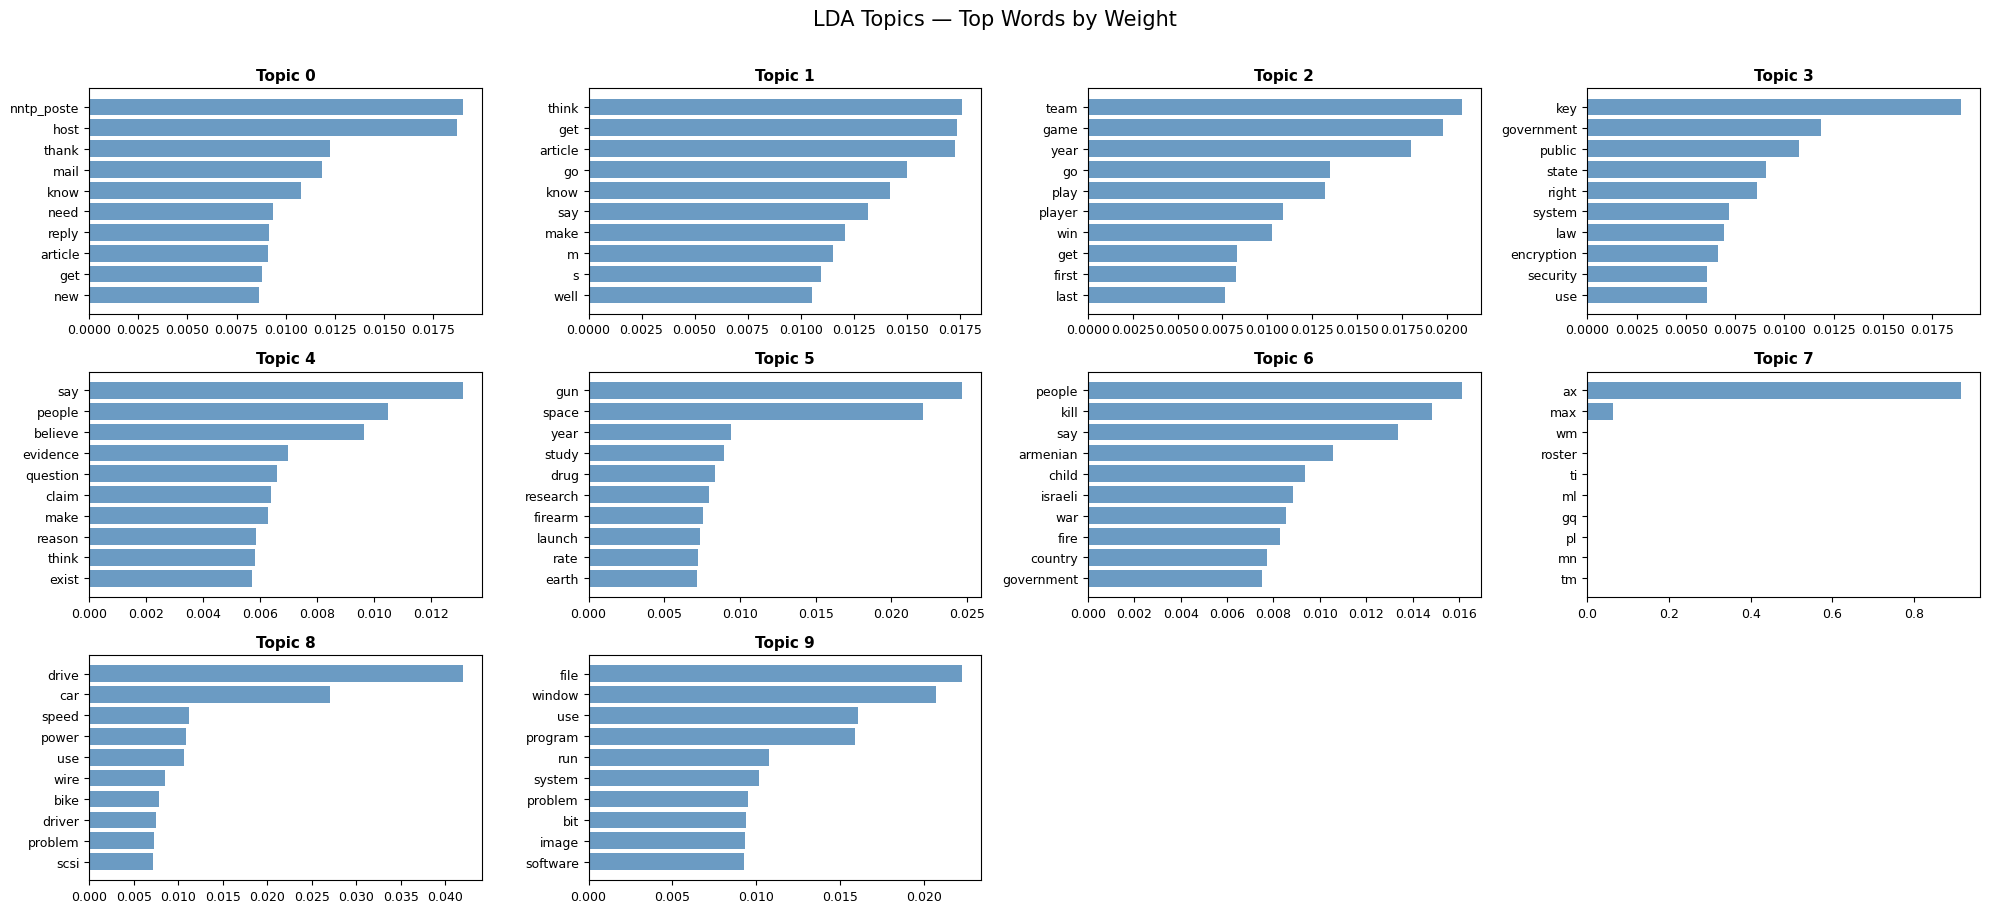

In [26]:
def plot_lda_topics(lda_model, num_topics, num_words=10):
    """Visualize LDA topics as horizontal bar charts."""
    topics = lda_model.show_topics(num_topics=num_topics, num_words=num_words, formatted=False)
    cols = 4
    rows = (len(topics) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 3), sharey=False)
    axes = axes.flatten()
    for idx, (topic_id, words) in enumerate(topics):
        ax = axes[idx]
        word_labels = [w for w, _ in words][::-1]
        word_weights = [float(p) for _, p in words][::-1]
        ax.barh(word_labels, word_weights, color='steelblue', alpha=0.8)
        ax.set_title(f'Topic {topic_id}', fontsize=11, fontweight='bold')
        ax.tick_params(axis='both', labelsize=9)
    for idx in range(len(topics), len(axes)):
        axes[idx].set_visible(False)
    plt.suptitle('LDA Topics — Top Words by Weight', fontsize=15, y=1.01)
    plt.tight_layout()
    plt.show()

plot_lda_topics(lda_model, NUM_TOPICS, num_words=10)

## 17. Dominant Topic per Document

In [27]:
def get_dominant_topic(ldamodel, corpus, texts):
    """Find the dominant topic for each document."""
    rows = []
    for i, row in enumerate(ldamodel[corpus]):
        # row is (doc_topics, word_topics, word_phi) when per_word_topics=True
        doc_topics = row[0] if isinstance(row[0], list) else row
        sorted_topics = sorted(doc_topics, key=lambda x: x[1], reverse=True)
        topic_num, prop_topic = sorted_topics[0]
        wp = ldamodel.show_topic(topic_num, topn=5)
        topic_keywords = ", ".join([word for word, prop in wp])
        rows.append([int(topic_num), round(prop_topic, 4), topic_keywords])
    
    df_topics = pd.DataFrame(rows, columns=['Dominant_Topic', 'Perc_Contribution', 'Topic_Keywords'])
    
    # Add original text
    contents = pd.Series([' '.join(t[:20]) + '...' for t in texts])
    df_topics = pd.concat([df_topics, contents.rename('Text_Preview')], axis=1)
    return df_topics

df_dominant_lda = get_dominant_topic(lda_model, corpus, data_lemmatized)
df_dominant_lda.head(10)

,Dominant_Topic,Perc_Contribution,Topic_Keywords,Text_Preview
0,0,0.3478,"nntp_poste, host, thank, mail, know",s thing car nntp_poste host rac_wam university...
1,0,0.5760,"nntp_poste, host, thank, mail, know",final call summary final call si clock report ...
2,1,0.4613,"think, get, article, go, know",question organization purdue_university engine...
3,0,0.4975,"nntp_poste, host, thank, mail, know",system division line distribution_world nntp_p...
4,1,0.3407,"think, get, article, go, know",question organization smithsonian_astrophysica...
5,4,0.2815,"say, people, believe, evidence, question",foxvog_dougla reword second_amendment idea org...
6,1,0.4232,"think, get, article, go, know",brian man delaney brain tumor treatment thank ...
7,8,0.5810,"drive, car, speed, power, use",organization line distribution_world nntp_post...
8,9,0.6022,"file, window, use, program, run",win icon help please organization university l...
9,0,0.4209,"nntp_poste, host, thank, mail, know",sigma_design double article pellettiere write ...


---# Part B — Non-negative Matrix Factorization (NMF)NMF decomposes the document-term matrix **V ≈ W × H** where all matrices have non-negative values.  Unlike LDA (probabilistic), NMF is a linear-algebra approach that often produces more coherent and interpretable topics.

## 18. NMF with Scikit-learn (TF-IDF based)

In [28]:
# Reconstruct clean text from lemmatized tokens for TF-IDF
texts_joined = [' '.join(doc) for doc in data_lemmatized]

# Build TF-IDF matrix
tfidf_vectorizer = TfidfVectorizer(
    max_df=0.5,        # ignore terms appearing in >50% of docs
    min_df=15,          # ignore terms appearing in <15 docs
    max_features=5000,  # keep top 5000 features
    stop_words='english'
)
tfidf_matrix = tfidf_vectorizer.fit_transform(texts_joined)
feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

TF-IDF matrix shape: (11314, 5000)


## 19. Train NMF Model (Scikit-learn)

In [30]:
NUM_TOPICS_NMF = 10

nmf_model = NMF(
    n_components=NUM_TOPICS_NMF,
    random_state=42,
    init='nndsvda',         # NNDSVD with zeros filled with small values (better for sparseness)
    solver='mu',            # Multiplicative Update solver
    beta_loss='kullback-leibler',  # KL-divergence loss (similar spirit to LDA)
    max_iter=500,
    alpha_W=0.1,            # L1/L2 regularization on W
    alpha_H=0.1,            # L1/L2 regularization on H
    l1_ratio=0.5            # balance between L1 and L2
)
W = nmf_model.fit_transform(tfidf_matrix)  # document-topic matrix
H = nmf_model.components_                   # topic-term matrix

print(f"Reconstruction error: {nmf_model.reconstruction_err_:.4f}")

Reconstruction error: 779.3051


## 20. Display NMF Topics

In [31]:
def display_nmf_topics(model, feature_names, num_words=7):
    """Display the top words for each NMF topic."""
    topics = []
    for topic_idx, topic in enumerate(model.components_):
        top_features = [feature_names[i] for i in topic.argsort()[:-num_words - 1:-1]]
        weights = [topic[i] for i in topic.argsort()[:-num_words - 1:-1]]
        topic_str = " + ".join([f"{w:.3f}*\"{f}\"" for f, w in zip(top_features, weights)])
        topics.append((topic_idx, topic_str))
        print(f"Topic {topic_idx:2d}: {', '.join(top_features)}")
    return topics

print("=== NMF Topics (Scikit-learn) ===\n")
nmf_topics = display_nmf_topics(nmf_model, feature_names, num_words=10)

=== NMF Topics (Scikit-learn) ===

Topic  0: article, nntp_poste, know, host, say, think, people, make, good, use
Topic  1: zoom, fake, fail, failed_president, failure, fair, fairly, faith, faithful, fall
Topic  2: zoom, fake, fail, failed_president, failure, fair, fairly, faith, faithful, fall
Topic  3: zoom, fake, fail, failed_president, failure, fair, fairly, faith, faithful, fall
Topic  4: zoom, fake, fail, failed_president, failure, fair, fairly, faith, faithful, fall
Topic  5: ax, max, wm, gq, sl, pl, au, ml, rk, mp
Topic  6: zoom, fake, fail, failed_president, failure, fair, fairly, faith, faithful, fall
Topic  7: zoom, fake, fail, failed_president, failure, fair, fairly, faith, faithful, fall
Topic  8: zoom, fake, fail, failed_president, failure, fair, fairly, faith, faithful, fall
Topic  9: zoom, fake, fail, failed_president, failure, fair, fairly, faith, faithful, fall


## 21. NMF with Gensim (Online / Streaming)

In [32]:
# Gensim's NMF works on the same BoW corpus as LDA — no TF-IDF needed
gensim_nmf = GensimNmf(
    corpus=corpus,
    id2word=id2word,
    num_topics=NUM_TOPICS_NMF,
    chunksize=2000,
    passes=5,
    kappa=1.0,
    random_state=42,
    eval_every=10,
    normalize=True
)

print("=== NMF Topics (Gensim Online) ===\n")
pprint(gensim_nmf.print_topics(num_words=10))

=== NMF Topics (Gensim Online) ===

[(0,
  '0.010*"get" + 0.010*"image" + 0.009*"available" + 0.008*"also" + '
  '0.008*"program" + 0.007*"include" + 0.007*"version" + 0.007*"window" + '
  '0.007*"widget" + 0.006*"use"'),
 (1,
  '0.013*"people" + 0.011*"go" + 0.009*"think" + 0.009*"say" + 0.009*"work" + '
  '0.008*"know" + 0.008*"s" + 0.007*"make" + 0.007*"get" + 0.007*"government"'),
 (2,
  '0.932*"ax" + 0.062*"max" + 0.001*"wm" + 0.000*"tm" + 0.000*"pl" + '
  '0.000*"mb" + 0.000*"sl" + 0.000*"part" + 0.000*"gq" + 0.000*"rk"'),
 (3,
  '0.062*"file" + 0.016*"entry" + 0.013*"program" + 0.008*"gun" + '
  '0.007*"output" + 0.007*"firearm" + 0.007*"use" + 0.006*"name" + 0.006*"get" '
  '+ 0.006*"build"'),
 (4,
  '0.022*"file" + 0.014*"internet" + 0.013*"image" + 0.012*"privacy" + '
  '0.011*"system" + 0.011*"mail" + 0.011*"information" + 0.010*"user" + '
  '0.009*"email" + 0.008*"computer"'),
 (5,
  '0.932*"ax" + 0.062*"max" + 0.001*"wm" + 0.000*"tm" + 0.000*"pl" + '
  '0.000*"sl" + 0.000*

## 22. Evaluate NMF — Coherence Score

In [33]:
# Coherence for Scikit-learn NMF
# We create a pseudo-gensim-compatible topic list for CoherenceModel
nmf_topic_words = []
for topic_idx, topic in enumerate(nmf_model.components_):
    top_word_indices = topic.argsort()[:-11:-1]
    nmf_topic_words.append([feature_names[i] for i in top_word_indices])

coherence_nmf = CoherenceModel(
    topics=nmf_topic_words,
    texts=data_lemmatized,
    dictionary=id2word,
    coherence='c_v'
)
print(f"NMF (sklearn) Coherence Score (c_v): {coherence_nmf.get_coherence():.4f}")

# Coherence for Gensim NMF
coherence_gensim_nmf = CoherenceModel(
    model=gensim_nmf,
    texts=data_lemmatized,
    dictionary=id2word,
    coherence='c_v'
)
print(f"NMF (Gensim)  Coherence Score (c_v): {coherence_gensim_nmf.get_coherence():.4f}")

# Recall LDA coherence
print(f"LDA           Coherence Score (c_v): {coherence_lda.get_coherence():.4f}")

NMF (sklearn) Coherence Score (c_v): 0.4251
NMF (Gensim)  Coherence Score (c_v): 0.5260
LDA           Coherence Score (c_v): 0.5546


## 23. NMF — Dominant Topic per Document

In [34]:
# Using sklearn NMF: W matrix has document-topic weights
df_nmf_dominant = pd.DataFrame({
    'Dominant_Topic': W.argmax(axis=1),
    'Topic_Weight': W.max(axis=1),
    'Text_Preview': [' '.join(doc[:20]) + '...' for doc in data_lemmatized]
})

# Add topic keywords
topic_keywords_map = {}
for idx, topic in enumerate(nmf_model.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-6:-1]]
    topic_keywords_map[idx] = ', '.join(top_words)

df_nmf_dominant['Topic_Keywords'] = df_nmf_dominant['Dominant_Topic'].map(topic_keywords_map)
df_nmf_dominant.head(10)

,Dominant_Topic,Topic_Weight,Text_Preview,Topic_Keywords
0,0,0.014472,s thing car nntp_poste host rac_wam university...,"article, nntp_poste, know, host, say"
1,0,0.016767,final call summary final call si clock report ...,"article, nntp_poste, know, host, say"
2,0,0.024693,question organization purdue_university engine...,"article, nntp_poste, know, host, say"
3,0,0.014645,system division line distribution_world nntp_p...,"article, nntp_poste, know, host, say"
4,0,0.016275,question organization smithsonian_astrophysica...,"article, nntp_poste, know, host, say"
5,0,0.018916,foxvog_dougla reword second_amendment idea org...,"article, nntp_poste, know, host, say"
6,0,0.013062,brian man delaney brain tumor treatment thank ...,"article, nntp_poste, know, host, say"
7,0,0.014189,organization line distribution_world nntp_post...,"article, nntp_poste, know, host, say"
8,0,0.008473,win icon help please organization university l...,"article, nntp_poste, know, host, say"
9,0,0.014526,sigma_design double article pellettiere write ...,"article, nntp_poste, know, host, say"


## 24. Compare LDA vs NMF — Topic Distribution

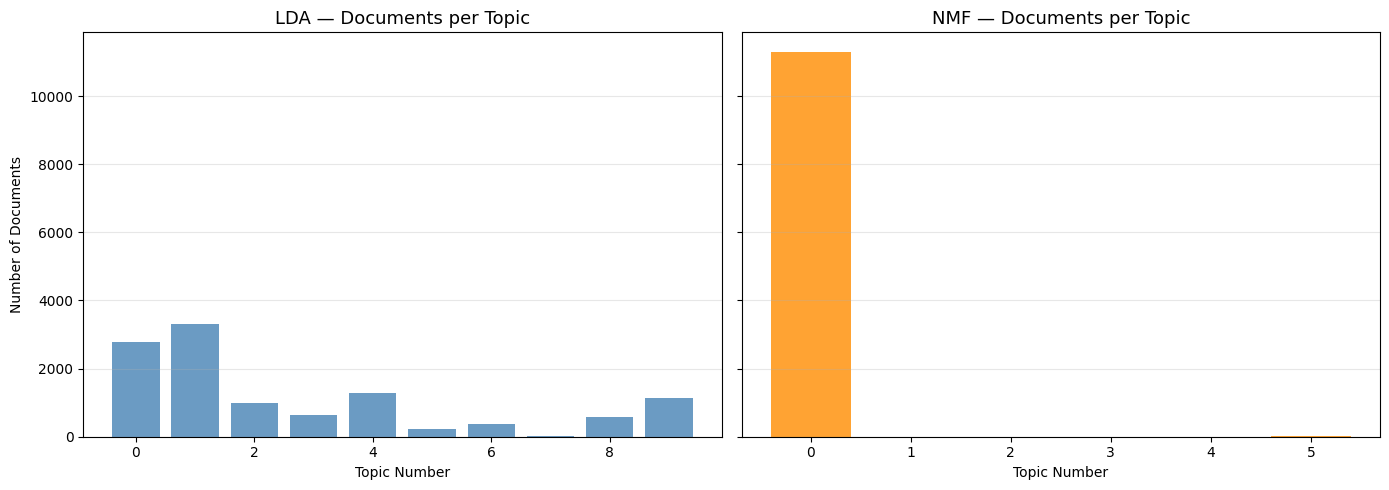

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# LDA topic distribution
lda_counts = df_dominant_lda['Dominant_Topic'].value_counts().sort_index()
axes[0].bar(lda_counts.index, lda_counts.values, color='steelblue', alpha=0.8)
axes[0].set_title('LDA — Documents per Topic', fontsize=13)
axes[0].set_xlabel('Topic Number')
axes[0].set_ylabel('Number of Documents')
axes[0].grid(axis='y', alpha=0.3)

# NMF topic distribution
nmf_counts = df_nmf_dominant['Dominant_Topic'].value_counts().sort_index()
axes[1].bar(nmf_counts.index, nmf_counts.values, color='darkorange', alpha=0.8)
axes[1].set_title('NMF — Documents per Topic', fontsize=13)
axes[1].set_xlabel('Topic Number')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()